# GPU STOMP with STUMPY

This notebook is a thesis-ready starting point for running a GPU-accelerated matrix profile on the processed BTCUSDT 1-minute dataset.

It keeps the same project-relative path pattern as the existing CPU notebook, but swaps the main compute step to `stumpy.gpu_stump` when CUDA is available.

In [1]:
from numba import cuda

print("CUDA available:", cuda.is_available())

if cuda.is_available():
    device = cuda.get_current_device()
    print("GPU:", device.name)
else:
    print("No CUDA GPU detected")

CUDA available: True
GPU: b'NVIDIA GeForce RTX 3060 Laptop GPU'


In [2]:
# Check CUDA visibility and run a basic GPU matrix calculation (A + B = C)

import numpy as np


if not cuda.is_available():
    print("CUDA accessible: False")
else:
    gpu_name = device.name.decode() if isinstance(device.name, bytes) else str(device.name)
    print("CUDA accessible: True")
    print(f"Active GPU: {gpu_name}")

    @cuda.jit
    def mat_add(a, b, c):
        i, j = cuda.grid(2)
        if i < c.shape[0] and j < c.shape[1]:
            c[i, j] = a[i, j] + b[i, j]

    # Small test matrices
    A = np.arange(16, dtype=np.float32).reshape(4, 4)
    B = np.ones((4, 4), dtype=np.float32) * 2
    C = np.zeros((4, 4), dtype=np.float32)

    # Move to GPU
    dA = cuda.to_device(A)
    dB = cuda.to_device(B)
    dC = cuda.to_device(C)

    # Launch kernel
    threads_per_block = (16, 16)
    blocks_per_grid_x = (C.shape[0] + threads_per_block[0] - 1) // threads_per_block[0]
    blocks_per_grid_y = (C.shape[1] + threads_per_block[1] - 1) // threads_per_block[1]
    mat_add[(blocks_per_grid_x, blocks_per_grid_y), threads_per_block](dA, dB, dC)

    # Copy result back
    C_result = dC.copy_to_host()

    print("A:\n", A)
    print("B:\n", B)
    print("C (GPU result):\n", C_result)
    print("Result correct:", np.allclose(C_result, A + B))

CUDA accessible: True
Active GPU: NVIDIA GeForce RTX 3060 Laptop GPU


c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\.thesis-env\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


A:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]]
B:
 [[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]
C (GPU result):
 [[ 2.  3.  4.  5.]
 [ 6.  7.  8.  9.]
 [10. 11. 12. 13.]
 [14. 15. 16. 17.]]
Result correct: True


## 1. Setup

If needed, install the repository dependencies from the project root:

```bash
pip install -r requirements.txt
```

For GPU execution, the Python environment also needs a working CUDA-capable setup that `numba.cuda` can detect.

In [3]:
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stumpy

plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
# Resolve paths relative to this notebook location.
project_root = Path("../../").resolve()
data_path = project_root / "data" / "processed" / "crypto" / "1min" / "BTCUSDT_1m_processed.parquet"

if not data_path.exists():
    raise FileNotFoundError(f"Processed dataset was not found at: {data_path}")

data_path

WindowsPath('C:/Users/learn/OneDrive/Desktop/Masters Thesis/MastersThesis/data/processed/crypto/1min/BTCUSDT_1m_processed.parquet')

## 2. Load the processed BTCUSDT data

In [5]:
df = pd.read_parquet(data_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Rows: 4,502,648
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']
Date range: 2017-08-17 04:00:00+00:00 -> 2026-03-15 23:59:00+00:00


## 3. Select a signal and one-year analysis window

`log_return` is a sensible first univariate signal for matrix profiling because it reduces long-run price trend dominance.

This notebook is configured to run on a full calendar year so the GPU path is used for a genuinely large experiment rather than a short debug sample.

In [6]:
candidate_column = "log_return"
analysis_year = 2025
year_start = pd.Timestamp(f"{analysis_year}-01-01 00:00:00", tz="UTC")
year_end = pd.Timestamp(f"{analysis_year + 1}-01-01 00:00:00", tz="UTC")

if candidate_column not in df.columns:
    raise KeyError(f"Expected column '{candidate_column}' was not found.")

signal_df = df[["timestamp", "close", candidate_column]].dropna().reset_index(drop=True)
signal_df = signal_df.rename(columns={candidate_column: "signal"})

sample_df = signal_df.loc[
    (signal_df["timestamp"] >= year_start) & (signal_df["timestamp"] < year_end)
].reset_index(drop=True).copy()

if sample_df.empty:
    raise ValueError(
        f"No rows were found for analysis_year={analysis_year}. "
        "Check the dataset coverage before running the GPU profile."
    )

signal = sample_df["signal"].to_numpy(dtype=np.float64)

print(f"Signal rows after dropping NaNs: {len(signal_df):,}")
print(f"Analysis rows used in this notebook: {len(sample_df):,}")
print(f"Analysis date range: {sample_df['timestamp'].min()} -> {sample_df['timestamp'].max()}")

Signal rows after dropping NaNs: 4,502,647
Analysis rows used in this notebook: 525,600
Analysis date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00


In [7]:
print(f"Sample date range: {sample_df['timestamp'].min()} -> {sample_df['timestamp'].max()}")

Sample date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00


## 4. Check GPU availability

If CUDA is visible to `numba`, the notebook will use `stumpy.gpu_stump`. Otherwise it falls back to `stumpy.stump` so you can still edit and validate the rest of the workflow.

In [8]:
gpu_available = False
gpu_error = None
gpu_name = None
gpu_total_memory_gb = None

try:
    from numba import cuda

    gpu_available = cuda.is_available()
    if gpu_available:
        device = cuda.get_current_device()
        gpu_name = device.name.decode() if isinstance(device.name, bytes) else device.name
        gpu_total_memory_gb = device.total_memory / (1024 ** 3)
except Exception as exc:
    gpu_error = repr(exc)

print(f"GPU available: {gpu_available}")
if gpu_name is not None:
    print(f"GPU name: {gpu_name}")
if gpu_total_memory_gb is not None:
    print(f"GPU memory (GB): {gpu_total_memory_gb:.2f}")
if gpu_error is not None:
    print(f"GPU probe error: {gpu_error}")

GPU available: True
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
GPU probe error: AttributeError('total_memory')


## 5. Run GPU STOMP

The `window` value is in minutes here because the dataset is 1-minute data. Adjust it to the motif duration you want to test.

In [9]:
window = 60
device_id = 0

if len(signal) <= window:
    raise ValueError("Signal length must be greater than the subsequence window.")

start = perf_counter()

if gpu_available:
    backend = "stumpy.gpu_stump"
    mp = stumpy.gpu_stump(signal, m=window, device_id=device_id)
else:
    backend = "stumpy.stump"
    warnings.warn(
        "CUDA GPU not available. Falling back to CPU STUMP so the notebook remains editable.",
        stacklevel=2,
    )
    mp = stumpy.stump(signal, m=window)

elapsed_seconds = perf_counter() - start

matrix_profile = np.asarray(mp[:, 0], dtype=np.float64)
nearest_neighbor_idx = np.asarray(mp[:, 1], dtype=np.int64)

print(f"Backend used: {backend}")
print(f"Window size: {window}")
print(f"Profile length: {len(matrix_profile):,}")
print(f"Elapsed seconds: {elapsed_seconds:,.2f}")

Backend used: stumpy.gpu_stump
Window size: 60
Profile length: 525,541
Elapsed seconds: 93.83


## 6. Inspect the matrix profile

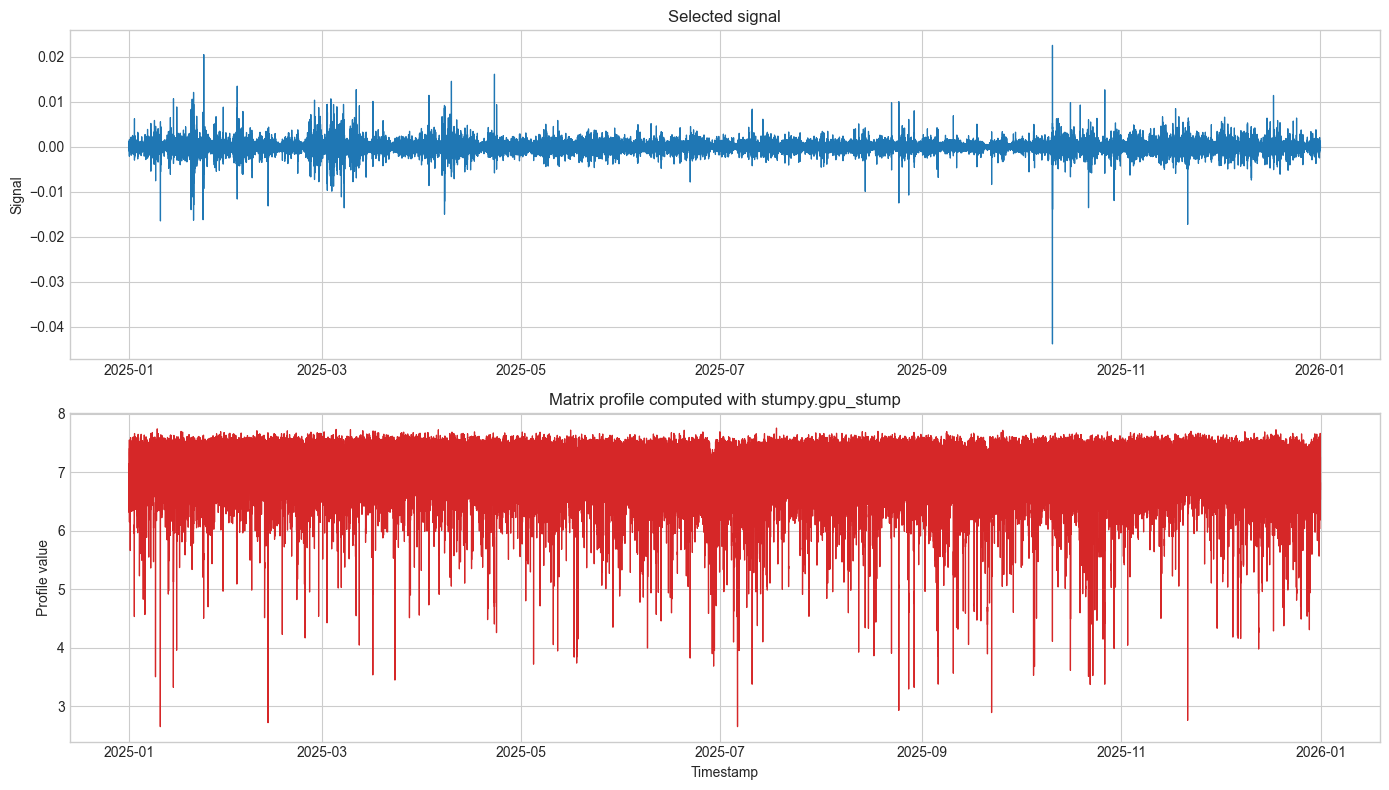

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(sample_df["timestamp"], sample_df["signal"], color="tab:blue", linewidth=0.9)
axes[0].set_title("Selected signal")
axes[0].set_ylabel("Signal")

profile_timestamps = sample_df["timestamp"].iloc[: len(matrix_profile)]
axes[1].plot(profile_timestamps, matrix_profile, color="tab:red", linewidth=0.9)
axes[1].set_title(f"Matrix profile computed with {backend}")
axes[1].set_ylabel("Profile value")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## 7. Extract top motifs and discords

In [11]:
def _overlaps(index_a: int, index_b: int, subseq_window: int) -> bool:
    return abs(index_a - index_b) < subseq_window


def top_non_overlapping_motifs(profile, neighbor_idx, subseq_window, k=5):
    motifs = []
    order = np.argsort(profile)

    for idx in order:
        if not np.isfinite(profile[idx]):
            continue

        nn_idx = int(neighbor_idx[idx])
        if nn_idx < 0:
            continue

        conflict = False
        for existing in motifs:
            if _overlaps(idx, existing["query_index"], subseq_window):
                conflict = True
                break
            if _overlaps(idx, existing["match_index"], subseq_window):
                conflict = True
                break
            if _overlaps(nn_idx, existing["query_index"], subseq_window):
                conflict = True
                break
            if _overlaps(nn_idx, existing["match_index"], subseq_window):
                conflict = True
                break

        if conflict:
            continue

        motifs.append(
            {
                "query_index": int(idx),
                "match_index": nn_idx,
                "profile_value": float(profile[idx]),
            }
        )

        if len(motifs) >= k:
            break

    return motifs


def top_non_overlapping_discords(profile, subseq_window, k=5):
    discords = []
    order = np.argsort(profile)[::-1]

    for idx in order:
        if not np.isfinite(profile[idx]):
            continue
        if any(_overlaps(idx, existing["index"], subseq_window) for existing in discords):
            continue

        discords.append({"index": int(idx), "profile_value": float(profile[idx])})
        if len(discords) >= k:
            break

    return discords


top_motifs = top_non_overlapping_motifs(matrix_profile, nearest_neighbor_idx, window, k=5)
top_discords = top_non_overlapping_discords(matrix_profile, window, k=5)

motif_df = pd.DataFrame(top_motifs)
if not motif_df.empty:
    motif_df["query_time"] = motif_df["query_index"].map(sample_df["timestamp"])
    motif_df["match_time"] = motif_df["match_index"].map(sample_df["timestamp"])

discord_df = pd.DataFrame(top_discords)
if not discord_df.empty:
    discord_df["timestamp"] = discord_df["index"].map(sample_df["timestamp"])

motif_df

,query_index,match_index,profile_value,query_time,match_time
0,13711,268369,2.653183,2025-01-10 12:31:00+00:00,2025-07-06 08:49:00+00:00
1,380463,339518,2.931639,2025-09-22 05:03:00+00:00,2025-08-24 18:38:00+00:00
2,346291,19471,3.324551,2025-08-29 11:31:00+00:00,2025-01-14 12:31:00+00:00
3,423964,466954,3.373826,2025-10-22 10:04:00+00:00,2025-11-21 06:34:00+00:00
4,430384,274818,3.378580,2025-10-26 21:04:00+00:00,2025-07-10 20:18:00+00:00


In [12]:
discord_df

,index,profile_value,timestamp
0,285557,7.756587,2025-07-18 07:17:00+00:00
1,12356,7.742789,2025-01-09 13:56:00+00:00
2,91260,7.733290,2025-03-05 09:00:00+00:00
3,97604,7.730010,2025-03-09 18:44:00+00:00
4,505923,7.728219,2025-12-18 08:03:00+00:00


## 8. Plot one motif pair

This is a compact starting visualization. Expand it if you want richer overlays or event annotations.

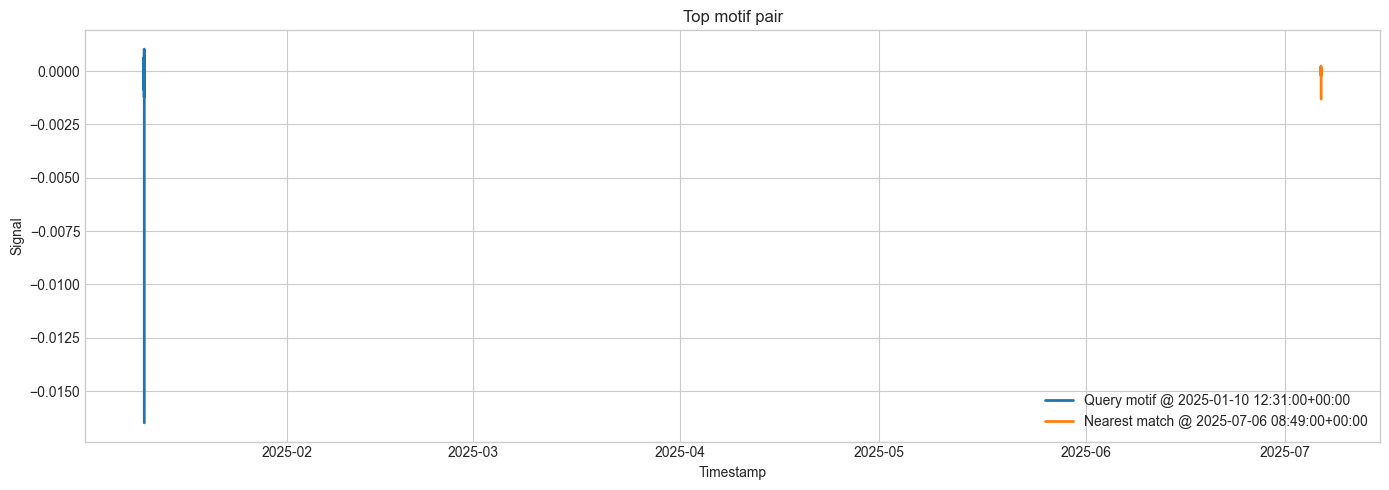

In [13]:
if motif_df.empty:
    print("No motif pair was selected.")
else:
    row = motif_df.iloc[0]
    query_slice = slice(int(row["query_index"]), int(row["query_index"]) + window)
    match_slice = slice(int(row["match_index"]), int(row["match_index"]) + window)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(
        sample_df["timestamp"].iloc[query_slice],
        sample_df["signal"].iloc[query_slice],
        label=f"Query motif @ {row['query_time']}",
        linewidth=2,
    )
    ax.plot(
        sample_df["timestamp"].iloc[match_slice],
        sample_df["signal"].iloc[match_slice],
        label=f"Nearest match @ {row['match_time']}",
        linewidth=2,
    )
    ax.set_title("Top motif pair")
    ax.set_ylabel("Signal")
    ax.set_xlabel("Timestamp")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Notes for further editing

- Change `analysis_year` if you want to profile a different full-year slice.
- Benchmark several `window` values to see which motif duration is most interpretable for BTC returns.
- If you want a direct CPU vs GPU timing comparison, duplicate the compute cell and force one run with `stumpy.stump` and one with `stumpy.gpu_stump`.
- Once the univariate run is stable, you can branch from here into multivariate motif experiments.